In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

dataset_file = 'Snappfood - Sentiment Analysis.csv'

df_snapp = pd.read_csv(dataset_file, sep='\t')
df_snapp = df_snapp.dropna(subset=['comment', 'label_id'])

X = df_snapp['comment'].astype(str).values
y = df_snapp['label_id'].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Total samples: {len(df_snapp)}")
print(f"Train samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Total samples: 69480
Train samples: 55584
Test samples: 13896


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

model_snapp = Pipeline([
    ('tfidf', TfidfVectorizer(min_df=3, max_df=0.9)),
    ('clf', MultinomialNB(alpha=1.0))
])

print()

Pipeline configured successfully.


In [3]:
from sklearn.metrics import classification_report

print("Training model on Snappfood dataset...")
model_snapp.fit(X_train, y_train)

print("Evaluating model...")
y_pred = model_snapp.predict(X_test)

print("\n" + "=" * 55)
print("Classification Report (Snappfood Sentiment Analysis)")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['Happy (0)', 'Sad (1)'], digits=4))

Training model on Snappfood dataset...
Evaluating model...

Classification Report (Snappfood Sentiment Analysis)
              precision    recall  f1-score   support

   Happy (0)     0.8858    0.7699    0.8238      6983
     Sad (1)     0.7947    0.8998    0.8440      6913

    accuracy                         0.8345     13896
   macro avg     0.8402    0.8348    0.8339     13896
weighted avg     0.8405    0.8345    0.8338     13896



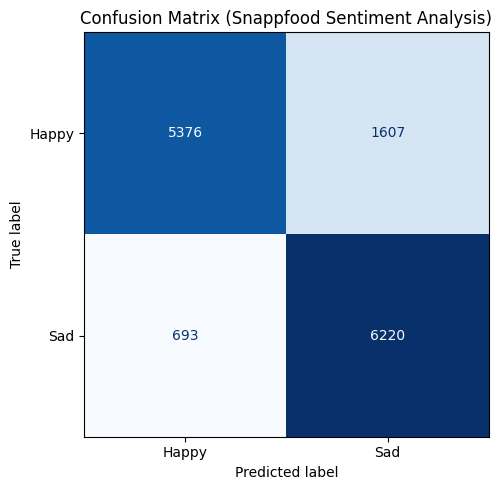

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Happy', 'Sad'],
    cmap='Blues',
    ax=ax,
    colorbar=False
)
plt.title("Confusion Matrix (Snappfood Sentiment Analysis)")
plt.tight_layout()
plt.show()